# Phase 2: Multi-Model Experiment — Legal Contract Analyzer
**Date:** 2026-04-14 | **Researcher:** Anthony Rodrigues | **Dataset:** CUAD v1

## Research Question
Phase 1 showed TF-IDF+LogReg achieves 0.642 macro-F1, within 0.008 of published RoBERTa-large (~0.650).
**Can we close the gap to published Legal-BERT (~0.85 micro-F1) by testing transformer architectures?**

## References Informing Today's Experiments
1. **Chalkidis et al. (2020)** — "LEGAL-BERT: The Muppets straight out of Law School" — Domain-pretraining on 12GB legal corpora gives +5-10% over BERT-base on legal NLP tasks.
2. **He et al. (2021)** — DeBERTa: Disentangled attention improves position-dependent token understanding, crucial for legal clause structure.
3. **Hendrycks et al. (2021)** — CUAD paper: RoBERTa-large gets ~0.65 macro-F1 with standard fine-tuning. Sliding window needed for full contract coverage.

## Experimental Plan
Six models across three paradigms:
- **Classical ML:** TF-IDF+SVM, TF-IDF+LightGBM
- **Dense embeddings:** Sentence-BERT + LogReg, Legal-BERT CLS + LogReg
- **Fine-tuned transformers:** BERT-base, Legal-BERT

All evaluated on same 80/20 split with macro-F1 as primary metric (per CUAD leaderboard).

In [1]:
import os, sys, json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Add project root to path
project_root = Path('.').resolve().parent
sys.path.insert(0, str(project_root / 'src'))

print(f'Project root: {project_root}')
print(f'Python: {sys.version}')

Project root: /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/Legal-Contract-Analyzer
Python: 3.14.3 (main, Feb  3 2026, 15:32:20) [Clang 17.0.0 (clang-1700.6.3.2)]


## 1. Data Loading — CUAD Multi-Label Classification
Reusing Mark's data pipeline from Phase 1. CUAD: 510 real SEC EDGAR contracts, 41 clause types.

In [2]:
import json as json_lib
from data_pipeline import (
    CUAD_CATEGORIES, RISK_CATEGORIES, HIGH_RISK_CLAUSES, MEDIUM_RISK_CLAUSES,
    map_question_to_category
)

# Load CUAD directly from JSON (pre-split: 408 train, 102 test)
def load_cuad_json(json_path):
    """Load CUAD SQuAD-format JSON and convert to classification DataFrame."""
    with open(json_path) as f:
        data = json_lib.load(f)
    
    rows = []
    for contract in data['data']:
        title = contract['title']
        full_text = ' '.join(p['context'] for p in contract['paragraphs'])
        labels = {}
        for para in contract['paragraphs']:
            for qa in para['qas']:
                cat = map_question_to_category(qa['question'])
                if cat:
                    is_present = len(qa['answers']) > 0 and any(
                        len(a.get('text', '').strip()) > 0 for a in qa['answers']
                    )
                    labels[cat] = max(labels.get(cat, 0), int(is_present))
        
        row = {'contract_title': title, 'text': full_text, 'text_length': len(full_text)}
        for cat in CUAD_CATEGORIES:
            row[cat] = labels.get(cat, 0)
        rows.append(row)
    
    return pd.DataFrame(rows)

# Load official train/test splits
train_raw = load_cuad_json(project_root / 'data' / 'raw' / 'train_separate_questions.json')
test_raw = load_cuad_json(project_root / 'data' / 'raw' / 'test.json')
print(f'Train contracts: {len(train_raw)}, Test contracts: {len(test_raw)}')

# Use risk-relevant clause columns
label_cols = [c for c in RISK_CATEGORIES if c in train_raw.columns]
print(f'Label columns: {len(label_cols)}')

# Clause prevalence
full_df = pd.concat([train_raw, test_raw])
prevalence = full_df[label_cols].mean().sort_values(ascending=False)
print(f'\nMost common clause: {prevalence.index[0]} ({prevalence.iloc[0]:.1%})')
print(f'Rarest clause: {prevalence.index[-1]} ({prevalence.iloc[-1]:.1%})')
print(f'Mean prevalence: {prevalence.mean():.1%}')


Train contracts: 408, Test contracts: 102
Label columns: 36

Most common clause: Governing Law (85.7%)
Rarest clause: Indemnification (0.0%)
Mean prevalence: 21.7%


In [3]:
# Use official CUAD train/test split (408/102)
train_texts = train_raw['text'].tolist()
test_texts = test_raw['text'].tolist()
y_train = train_raw[label_cols].values
y_test = test_raw[label_cols].values

print(f'Train: {len(train_texts)} contracts, Test: {len(test_texts)} contracts')
print(f'Labels shape: train={y_train.shape}, test={y_test.shape}')
print(f'Avg labels per contract: train={y_train.sum(axis=1).mean():.1f}, test={y_test.sum(axis=1).mean():.1f}')


Train: 408 contracts, Test: 102 contracts
Labels shape: train=(408, 36), test=(102, 36)
Avg labels per contract: train=8.0, test=7.0


## 2. Evaluation Framework
Consistent evaluation across all models: macro-F1 (primary), micro-F1, macro-AUC, per-clause breakdown.

In [4]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

def evaluate_multilabel(y_true, y_pred, y_prob=None, label_names=None):
    """Evaluate multi-label predictions. Returns dict of metrics."""
    # Filter to clauses with at least 1 positive in test set
    active_mask = y_true.sum(axis=0) > 0
    y_t = y_true[:, active_mask]
    y_p = y_pred[:, active_mask]
    
    results = {
        'macro_f1': f1_score(y_t, y_p, average='macro', zero_division=0),
        'micro_f1': f1_score(y_t, y_p, average='micro', zero_division=0),
        'macro_precision': precision_score(y_t, y_p, average='macro', zero_division=0),
        'macro_recall': recall_score(y_t, y_p, average='macro', zero_division=0),
        'n_active_clauses': int(active_mask.sum()),
    }
    
    # AUC requires probabilities
    if y_prob is not None:
        y_prb = y_prob[:, active_mask]
        try:
            # Per-clause AUC, then average (skip clauses with only 1 class in test)
            aucs = []
            for i in range(y_t.shape[1]):
                if len(np.unique(y_t[:, i])) > 1:
                    aucs.append(roc_auc_score(y_t[:, i], y_prb[:, i]))
            results['macro_auc'] = np.mean(aucs) if aucs else 0.0
            results['n_auc_clauses'] = len(aucs)
        except Exception:
            results['macro_auc'] = 0.0
    
    # Per-clause F1 for detailed analysis
    if label_names is not None:
        active_names = [label_names[i] for i in range(len(label_names)) if active_mask[i]]
        per_clause = {}
        for j, name in enumerate(active_names):
            per_clause[name] = {
                'f1': f1_score(y_t[:, j], y_p[:, j], zero_division=0),
                'precision': precision_score(y_t[:, j], y_p[:, j], zero_division=0),
                'recall': recall_score(y_t[:, j], y_p[:, j], zero_division=0),
            }
        results['per_clause'] = per_clause
    
    return results

# Store all experiment results
all_results = {}
print('Evaluation framework ready.')

Evaluation framework ready.


---
## Experiment 2.1: TF-IDF + SVM (Linear)
**Hypothesis:** SVM with linear kernel maximizes margin in high-dimensional TF-IDF space. Should outperform LogReg on rare clauses where the decision boundary is tight.

**Why SVM:** Chalkidis et al. (2022) showed SVM competitive with LogReg on LexGLUE tasks. The max-margin objective may help with imbalanced classes where LogReg's log-loss can be dominated by majority class.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.multiclass import OneVsRestClassifier

# TF-IDF features (same settings as Phase 1 for fair comparison)
print('Building TF-IDF matrix...')
tfidf = TfidfVectorizer(
    max_features=50000, ngram_range=(1, 2),
    sublinear_tf=True, smooth_idf=True, strip_accents='unicode'
)
X_train_tfidf = tfidf.fit_transform(train_texts)
X_test_tfidf = tfidf.transform(test_texts)
print(f'TF-IDF shape: train={X_train_tfidf.shape}, test={X_test_tfidf.shape}')

# Train LinearSVC with calibration (for probability output)
print('Training SVM (OneVsRest, 36 classifiers)...')
t0 = time.time()
svm_model = OneVsRestClassifier(
    CalibratedClassifierCV(
        LinearSVC(C=1.0, class_weight='balanced', max_iter=5000, dual='auto'),
        cv=3
    ),
    n_jobs=-1
)
svm_model.fit(X_train_tfidf, y_train)
svm_time = time.time() - t0

# Predict
y_pred_svm = svm_model.predict(X_test_tfidf)
y_prob_svm = svm_model.predict_proba(X_test_tfidf)

# Evaluate
svm_results = evaluate_multilabel(y_test, y_pred_svm, y_prob_svm, label_cols)
svm_results['train_time_s'] = svm_time
all_results['TF-IDF + SVM'] = svm_results

print(f'\nTF-IDF + SVM Results (trained in {svm_time:.1f}s):')
print(f'  Macro-F1: {svm_results["macro_f1"]:.4f}')
print(f'  Micro-F1: {svm_results["micro_f1"]:.4f}')
print(f'  Macro-AUC: {svm_results.get("macro_auc", 0):.4f}')
print(f'  Precision: {svm_results["macro_precision"]:.4f}')
print(f'  Recall: {svm_results["macro_recall"]:.4f}')

Building TF-IDF matrix...


TF-IDF shape: train=(408, 50000), test=(102, 50000)
Training SVM (OneVsRest, 36 classifiers)...



TF-IDF + SVM Results (trained in 2.8s):
  Macro-F1: 0.5316
  Micro-F1: 0.7181
  Macro-AUC: 0.8721
  Precision: 0.6472
  Recall: 0.4878


---
## Experiment 2.2: TF-IDF + LightGBM
**Hypothesis:** Gradient boosting captures non-linear interactions between TF-IDF features that linear models miss. If "indemnification" AND "uncapped" appear together, the risk is different than either alone.

**Why LightGBM:** Fast on sparse matrices, handles class imbalance via scale_pos_weight, and can capture feature interactions without explicit engineering.

In [6]:
import lightgbm as lgb

print('Training LightGBM (one per clause)...')
t0 = time.time()

y_pred_lgb = np.zeros_like(y_test)
y_prob_lgb = np.zeros_like(y_test, dtype=float)

for i, col in enumerate(label_cols):
    n_pos = y_train[:, i].sum()
    n_neg = len(y_train) - n_pos
    
    if n_pos < 3:  # Skip clauses with <3 positive training examples
        y_pred_lgb[:, i] = 0
        y_prob_lgb[:, i] = 0.0
        continue
    
    spw = n_neg / max(n_pos, 1)
    
    model = lgb.LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=spw, num_leaves=31,
        min_child_samples=5, subsample=0.8,
        verbosity=-1, n_jobs=-1, random_state=42
    )
    model.fit(X_train_tfidf, y_train[:, i])
    y_prob_lgb[:, i] = model.predict_proba(X_test_tfidf)[:, 1]
    y_pred_lgb[:, i] = (y_prob_lgb[:, i] >= 0.5).astype(int)

lgb_time = time.time() - t0

lgb_results = evaluate_multilabel(y_test, y_pred_lgb, y_prob_lgb, label_cols)
lgb_results['train_time_s'] = lgb_time
all_results['TF-IDF + LightGBM'] = lgb_results

print(f'\nTF-IDF + LightGBM Results (trained in {lgb_time:.1f}s):')
print(f'  Macro-F1: {lgb_results["macro_f1"]:.4f}')
print(f'  Micro-F1: {lgb_results["micro_f1"]:.4f}')
print(f'  Macro-AUC: {lgb_results.get("macro_auc", 0):.4f}')
print(f'  Precision: {lgb_results["macro_precision"]:.4f}')
print(f'  Recall: {lgb_results["macro_recall"]:.4f}')

Training LightGBM (one per clause)...



TF-IDF + LightGBM Results (trained in 202.2s):
  Macro-F1: 0.5750
  Micro-F1: 0.7719
  Macro-AUC: 0.9059
  Precision: 0.6958
  Recall: 0.5249


## Observation: Classical ML Comparison
Let me compare SVM and LightGBM against Mark's Phase 1 TF-IDF+LogReg (0.642 macro-F1) before moving to transformers.

In [7]:
# Mark's Phase 1 baseline for comparison
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier as OVR

print('Reproducing Mark Phase 1 baseline (TF-IDF + LogReg)...')
t0 = time.time()
lr_model = OVR(LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, solver='lbfgs'), n_jobs=-1)
lr_model.fit(X_train_tfidf, y_train)
lr_time = time.time() - t0

y_pred_lr = lr_model.predict(X_test_tfidf)
y_prob_lr = lr_model.predict_proba(X_test_tfidf)

lr_results = evaluate_multilabel(y_test, y_pred_lr, y_prob_lr, label_cols)
lr_results['train_time_s'] = lr_time
all_results['TF-IDF + LogReg (baseline)'] = lr_results

print(f'TF-IDF + LogReg: macro-F1={lr_results["macro_f1"]:.4f} (Mark reported 0.642)')
print(f'TF-IDF + SVM:    macro-F1={all_results["TF-IDF + SVM"]["macro_f1"]:.4f} (delta: {all_results["TF-IDF + SVM"]["macro_f1"] - lr_results["macro_f1"]:+.4f})')
print(f'TF-IDF + LightGBM: macro-F1={all_results["TF-IDF + LightGBM"]["macro_f1"]:.4f} (delta: {all_results["TF-IDF + LightGBM"]["macro_f1"] - lr_results["macro_f1"]:+.4f})')

Reproducing Mark Phase 1 baseline (TF-IDF + LogReg)...


TF-IDF + LogReg: macro-F1=0.5669 (Mark reported 0.642)
TF-IDF + SVM:    macro-F1=0.5316 (delta: -0.0352)
TF-IDF + LightGBM: macro-F1=0.5750 (delta: +0.0082)


---
## Experiment 2.3: Sentence-BERT Embeddings + LogReg
**Hypothesis:** Dense sentence embeddings capture semantic meaning that TF-IDF n-grams miss. "The company may terminate at its discretion" and "Termination is at the sole option of the party" should map to similar embeddings despite no lexical overlap.

**Challenge:** Contracts average 7,861 words. Sentence-BERT has a 512-token limit. I'll use mean-pooling over 512-token chunks as a proxy for full-document embedding.

**Model:** all-MiniLM-L6-v2 (384d, fast, good general-purpose embeddings)

In [8]:
from sentence_transformers import SentenceTransformer

print('Loading Sentence-BERT (all-MiniLM-L6-v2)...')
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

def encode_long_texts(model, texts, max_chunk_tokens=400, batch_size=32):
    """Encode long documents by chunking and mean-pooling."""
    all_embeddings = []
    for text in texts:
        # Simple word-level chunking (approximation)
        words = text.split()
        chunks = []
        for start in range(0, len(words), max_chunk_tokens):
            chunk = ' '.join(words[start:start + max_chunk_tokens])
            chunks.append(chunk)
        
        if not chunks:
            chunks = [text[:1000]]
        
        # Encode all chunks and mean-pool
        chunk_embs = model.encode(chunks, batch_size=batch_size, show_progress_bar=False)
        doc_emb = np.mean(chunk_embs, axis=0)
        all_embeddings.append(doc_emb)
    
    return np.array(all_embeddings)

print('Encoding train contracts...')
t0 = time.time()
X_train_sbert = encode_long_texts(sbert_model, train_texts)
print(f'Encoding test contracts...')
X_test_sbert = encode_long_texts(sbert_model, test_texts)
sbert_encode_time = time.time() - t0
print(f'Sentence-BERT embeddings: train={X_train_sbert.shape}, test={X_test_sbert.shape}')
print(f'Encoding time: {sbert_encode_time:.1f}s')

Loading Sentence-BERT (all-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding train contracts...


Encoding test contracts...


Sentence-BERT embeddings: train=(408, 384), test=(102, 384)
Encoding time: 44.1s


In [9]:
# Train LogReg on SBERT embeddings
print('Training LogReg on Sentence-BERT embeddings...')
t0 = time.time()
sbert_lr = OVR(LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, solver='lbfgs'), n_jobs=-1)
sbert_lr.fit(X_train_sbert, y_train)
sbert_lr_time = time.time() - t0 + sbert_encode_time

y_pred_sbert = sbert_lr.predict(X_test_sbert)
y_prob_sbert = sbert_lr.predict_proba(X_test_sbert)

sbert_results = evaluate_multilabel(y_test, y_pred_sbert, y_prob_sbert, label_cols)
sbert_results['train_time_s'] = sbert_lr_time
all_results['SBERT + LogReg'] = sbert_results

print(f'\nSBERT + LogReg Results (total time {sbert_lr_time:.1f}s):')
print(f'  Macro-F1: {sbert_results["macro_f1"]:.4f}')
print(f'  Micro-F1: {sbert_results["micro_f1"]:.4f}')
print(f'  Macro-AUC: {sbert_results.get("macro_auc", 0):.4f}')
print(f'  Delta vs TF-IDF+LR: {sbert_results["macro_f1"] - lr_results["macro_f1"]:+.4f}')

Training LogReg on Sentence-BERT embeddings...



SBERT + LogReg Results (total time 45.4s):
  Macro-F1: 0.4721
  Micro-F1: 0.5795
  Macro-AUC: 0.7855
  Delta vs TF-IDF+LR: -0.0947


---
## Experiment 2.4: Legal-BERT CLS Embeddings + LogReg
**Hypothesis:** Legal-BERT (nlpaueb/legal-bert-base-uncased), pre-trained on 12GB of legal corpora, should produce better legal clause representations than general-purpose Sentence-BERT. The CLS token embedding captures document-level semantics trained on legal language.

**Method:** Extract CLS token from Legal-BERT for each 512-token chunk, mean-pool across chunks, then LogReg.

In [10]:
import torch
from transformers import AutoTokenizer, AutoModel

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

print('Loading Legal-BERT...')
legal_tokenizer = AutoTokenizer.from_pretrained('nlpaueb/legal-bert-base-uncased')
legal_model = AutoModel.from_pretrained('nlpaueb/legal-bert-base-uncased').to(device)
legal_model.eval()
print(f'Legal-BERT loaded: {sum(p.numel() for p in legal_model.parameters())/1e6:.0f}M params')

Device: mps
Loading Legal-BERT...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Legal-BERT loaded: 109M params


In [11]:
def extract_cls_embeddings(tokenizer, model, texts, max_length=512, device='mps'):
    """Extract CLS embeddings from transformer, chunking long documents."""
    all_embeddings = []
    model.eval()
    
    with torch.no_grad():
        for idx, text in enumerate(texts):
            # Tokenize full text
            tokens = tokenizer(text, return_tensors='pt', truncation=False, add_special_tokens=False)
            input_ids = tokens['input_ids'][0]
            
            # Chunk into max_length-2 pieces (leave room for [CLS] and [SEP])
            chunk_size = max_length - 2
            chunks_embs = []
            
            for start in range(0, len(input_ids), chunk_size):
                chunk_ids = input_ids[start:start + chunk_size]
                # Add [CLS] and [SEP]
                chunk_ids = torch.cat([
                    torch.tensor([tokenizer.cls_token_id]),
                    chunk_ids,
                    torch.tensor([tokenizer.sep_token_id])
                ])
                attention_mask = torch.ones_like(chunk_ids)
                
                out = model(
                    input_ids=chunk_ids.unsqueeze(0).to(device),
                    attention_mask=attention_mask.unsqueeze(0).to(device)
                )
                cls_emb = out.last_hidden_state[0, 0].cpu().numpy()
                chunks_embs.append(cls_emb)
            
            # Mean-pool all chunk CLS embeddings
            doc_emb = np.mean(chunks_embs, axis=0)
            all_embeddings.append(doc_emb)
            
            if (idx + 1) % 50 == 0:
                print(f'  Encoded {idx+1}/{len(texts)} contracts')
    
    return np.array(all_embeddings)

print('Extracting Legal-BERT CLS embeddings for train set...')
t0 = time.time()
X_train_legal = extract_cls_embeddings(legal_tokenizer, legal_model, train_texts, device=device)
print('Extracting for test set...')
X_test_legal = extract_cls_embeddings(legal_tokenizer, legal_model, test_texts, device=device)
legal_encode_time = time.time() - t0
print(f'Legal-BERT embeddings: train={X_train_legal.shape}, test={X_test_legal.shape}')
print(f'Encoding time: {legal_encode_time:.1f}s')

Token indices sequence length is longer than the specified maximum sequence length for this model (7369 > 512). Running this sequence through the model will result in indexing errors


Extracting Legal-BERT CLS embeddings for train set...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

  Encoded 50/408 contracts


  Encoded 100/408 contracts


...

  Encoded 400/408 contracts


Extracting for test set...


  Encoded 50/102 contracts


  Encoded 100/102 contracts


Legal-BERT embeddings: train=(408, 768), test=(102, 768)
Encoding time: 498.4s


In [12]:
# Train LogReg on Legal-BERT embeddings
print('Training LogReg on Legal-BERT embeddings...')
t0 = time.time()
legal_lr = OVR(LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, solver='lbfgs'), n_jobs=-1)
legal_lr.fit(X_train_legal, y_train)
legal_lr_time = time.time() - t0 + legal_encode_time

y_pred_legal = legal_lr.predict(X_test_legal)
y_prob_legal = legal_lr.predict_proba(X_test_legal)

legal_results = evaluate_multilabel(y_test, y_pred_legal, y_prob_legal, label_cols)
legal_results['train_time_s'] = legal_lr_time
all_results['Legal-BERT CLS + LogReg'] = legal_results

print(f'\nLegal-BERT CLS + LogReg Results (total time {legal_lr_time:.1f}s):')
print(f'  Macro-F1: {legal_results["macro_f1"]:.4f}')
print(f'  Micro-F1: {legal_results["micro_f1"]:.4f}')
print(f'  Macro-AUC: {legal_results.get("macro_auc", 0):.4f}')
print(f'  Delta vs TF-IDF+LR: {legal_results["macro_f1"] - lr_results["macro_f1"]:+.4f}')
print(f'  Delta vs SBERT: {legal_results["macro_f1"] - sbert_results["macro_f1"]:+.4f}')

# Free GPU memory
del legal_model
torch.mps.empty_cache() if hasattr(torch.mps, 'empty_cache') else None

Training LogReg on Legal-BERT embeddings...



Legal-BERT CLS + LogReg Results (total time 502.2s):
  Macro-F1: 0.5144
  Micro-F1: 0.6525
  Macro-AUC: 0.8111
  Delta vs TF-IDF+LR: -0.0524
  Delta vs SBERT: +0.0423


---
## Experiment 2.5: BERT-base Fine-tuned (Multi-label)
**Hypothesis:** Fine-tuning adapts BERT's representations to the specific clause detection task, unlike frozen embeddings. The model learns which attention patterns matter for legal clause identification.

**Method:** bert-base-uncased with a multi-label classification head (36 outputs). Truncated to 512 tokens (first tokens only — known limitation). Binary cross-entropy loss with pos_weight for class imbalance.

**Limitation:** Truncation to 512 tokens means we miss clauses appearing late in contracts. Phase 3 will explore sliding window.

In [13]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

class ContractDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.encodings = tokenizer(
            texts, truncation=True, padding=True,
            max_length=max_length, return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.float32)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

def train_transformer(model_name, train_texts, y_train, test_texts, y_test,
                       num_labels, epochs=5, batch_size=8, lr=2e-5, device='mps'):
    """Fine-tune a transformer for multi-label classification."""
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=num_labels,
        problem_type='multi_label_classification'
    ).to(device)
    
    # Compute pos_weight for class imbalance
    pos_counts = y_train.sum(axis=0)
    neg_counts = len(y_train) - pos_counts
    pos_weight = torch.tensor(neg_counts / np.maximum(pos_counts, 1), dtype=torch.float32).to(device)
    pos_weight = torch.clamp(pos_weight, max=20.0)  # Cap extreme weights
    
    train_dataset = ContractDataset(train_texts, y_train, tokenizer)
    test_dataset = ContractDataset(test_texts, y_test, tokenizer)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)
    
    # Training loop
    loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    train_losses = []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f'  Epoch {epoch+1}/{epochs}: loss={avg_loss:.4f}')
    
    # Evaluation
    model.eval()
    all_logits = []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            all_logits.append(outputs.logits.cpu())
    
    logits = torch.cat(all_logits, dim=0)
    probs = torch.sigmoid(logits).numpy()
    preds = (probs >= 0.5).astype(int)
    
    return preds, probs, train_losses, model, tokenizer

print('Transformer training framework ready.')
print(f'Num labels: {len(label_cols)}')
print(f'Device: {device}')

Transformer training framework ready.
Num labels: 36
Device: mps


In [14]:
# Fine-tune BERT-base
print('=== Fine-tuning BERT-base-uncased ===')
t0 = time.time()
y_pred_bert, y_prob_bert, bert_losses, _, _ = train_transformer(
    'bert-base-uncased', train_texts, y_train, test_texts, y_test,
    num_labels=len(label_cols), epochs=5, batch_size=8, lr=2e-5, device=device
)
bert_time = time.time() - t0

bert_results = evaluate_multilabel(y_test, y_pred_bert, y_prob_bert, label_cols)
bert_results['train_time_s'] = bert_time
bert_results['train_losses'] = bert_losses
all_results['BERT-base (fine-tuned)'] = bert_results

print(f'\nBERT-base Fine-tuned Results (trained in {bert_time:.1f}s):')
print(f'  Macro-F1: {bert_results["macro_f1"]:.4f}')
print(f'  Micro-F1: {bert_results["micro_f1"]:.4f}')
print(f'  Macro-AUC: {bert_results.get("macro_auc", 0):.4f}')
print(f'  Delta vs TF-IDF+LR: {bert_results["macro_f1"] - lr_results["macro_f1"]:+.4f}')

# Free memory
import gc
gc.collect()
torch.mps.empty_cache() if hasattr(torch.mps, 'empty_cache') else None

=== Fine-tuning BERT-base-uncased ===


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

  Epoch 2/5: loss=0.8617


  Epoch 3/5: loss=0.8295


  Epoch 4/5: loss=0.8055


  Epoch 5/5: loss=0.7920



BERT-base Fine-tuned Results (trained in 406.3s):
  Macro-F1: 0.3501
  Micro-F1: 0.4334
  Macro-AUC: 0.6373
  Delta vs TF-IDF+LR: -0.2167


---
## Experiment 2.6: Legal-BERT Fine-tuned (Multi-label)
**Hypothesis:** Legal-BERT (nlpaueb/legal-bert-base-uncased), pre-trained on 12GB of legal text, should outperform BERT-base on legal clause detection because its vocabulary and representations are tuned to legal language patterns.

**Key test:** Does domain pre-training matter more than general pre-training for this specific task?

In [15]:
print('=== Fine-tuning Legal-BERT ===')
t0 = time.time()
y_pred_lbert, y_prob_lbert, lbert_losses, _, _ = train_transformer(
    'nlpaueb/legal-bert-base-uncased', train_texts, y_train, test_texts, y_test,
    num_labels=len(label_cols), epochs=5, batch_size=8, lr=2e-5, device=device
)
lbert_time = time.time() - t0

lbert_results = evaluate_multilabel(y_test, y_pred_lbert, y_prob_lbert, label_cols)
lbert_results['train_time_s'] = lbert_time
lbert_results['train_losses'] = lbert_losses
all_results['Legal-BERT (fine-tuned)'] = lbert_results

print(f'\nLegal-BERT Fine-tuned Results (trained in {lbert_time:.1f}s):')
print(f'  Macro-F1: {lbert_results["macro_f1"]:.4f}')
print(f'  Micro-F1: {lbert_results["micro_f1"]:.4f}')
print(f'  Macro-AUC: {lbert_results.get("macro_auc", 0):.4f}')
print(f'  Delta vs TF-IDF+LR: {lbert_results["macro_f1"] - lr_results["macro_f1"]:+.4f}')
print(f'  Delta vs BERT-base: {lbert_results["macro_f1"] - bert_results["macro_f1"]:+.4f}')

gc.collect()
torch.mps.empty_cache() if hasattr(torch.mps, 'empty_cache') else None

=== Fine-tuning Legal-BERT ===


You passed `num_labels=36` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were new

  Epoch 1/5: loss=0.9380


  Epoch 2/5: loss=0.8608


  Epoch 3/5: loss=0.8236


  Epoch 4/5: loss=0.7967


  Epoch 5/5: loss=0.7766



Legal-BERT Fine-tuned Results (trained in 299.5s):
  Macro-F1: 0.4098
  Micro-F1: 0.4828
  Macro-AUC: 0.6946
  Delta vs TF-IDF+LR: -0.1570
  Delta vs BERT-base: +0.0597


---
## Head-to-Head Comparison: All 6 Models
The moment of truth: which paradigm wins on CUAD multi-label clause detection?

In [16]:
# Build comparison table
comparison = []
for name, res in all_results.items():
    comparison.append({
        'Model': name,
        'Macro-F1': res['macro_f1'],
        'Micro-F1': res['micro_f1'],
        'Precision': res['macro_precision'],
        'Recall': res['macro_recall'],
        'AUC': res.get('macro_auc', 0),
        'Time (s)': res['train_time_s'],
    })

comp_df = pd.DataFrame(comparison).sort_values('Macro-F1', ascending=False)
comp_df['Rank'] = range(1, len(comp_df) + 1)
comp_df = comp_df[['Rank', 'Model', 'Macro-F1', 'Micro-F1', 'Precision', 'Recall', 'AUC', 'Time (s)']]

print('\n' + '='*100)
print('PHASE 2: HEAD-TO-HEAD MODEL COMPARISON — CUAD Multi-Label Clause Detection')
print('='*100)
print(comp_df.to_string(index=False, float_format='%.4f'))
print('\nPublished benchmarks: RoBERTa-large ~0.650, Legal-BERT published ~0.85 micro-F1')

# Highlight key findings
best = comp_df.iloc[0]
worst = comp_df.iloc[-1]
print(f'\nBest: {best["Model"]} (Macro-F1={best["Macro-F1"]:.4f})')
print(f'Worst: {worst["Model"]} (Macro-F1={worst["Macro-F1"]:.4f})')
print(f'Spread: {best["Macro-F1"] - worst["Macro-F1"]:.4f}')


PHASE 2: HEAD-TO-HEAD MODEL COMPARISON — CUAD Multi-Label Clause Detection
 Rank                      Model  Macro-F1  Micro-F1  Precision  Recall    AUC  Time (s)
    1          TF-IDF + LightGBM    0.5750    0.7719     0.6958  0.5249 0.9059  202.1550
    2 TF-IDF + LogReg (baseline)    0.5669    0.7118     0.5979  0.5717 0.8693    0.3364
    3               TF-IDF + SVM    0.5316    0.7181     0.6472  0.4878 0.8721    2.7779
    4    Legal-BERT CLS + LogReg    0.5144    0.6525     0.4937  0.5480 0.8111  502.2134
    5             SBERT + LogReg    0.4721    0.5795     0.4091  0.6078 0.7855   45.3576
    6    Legal-BERT (fine-tuned)    0.4098    0.4828     0.3693  0.5529 0.6946  299.4873
    7     BERT-base (fine-tuned)    0.3501    0.4334     0.3113  0.5206 0.6373  406.2703

Published benchmarks: RoBERTa-large ~0.650, Legal-BERT published ~0.85 micro-F1

Best: TF-IDF + LightGBM (Macro-F1=0.5750)
Worst: BERT-base (fine-tuned) (Macro-F1=0.3501)
Spread: 0.2249


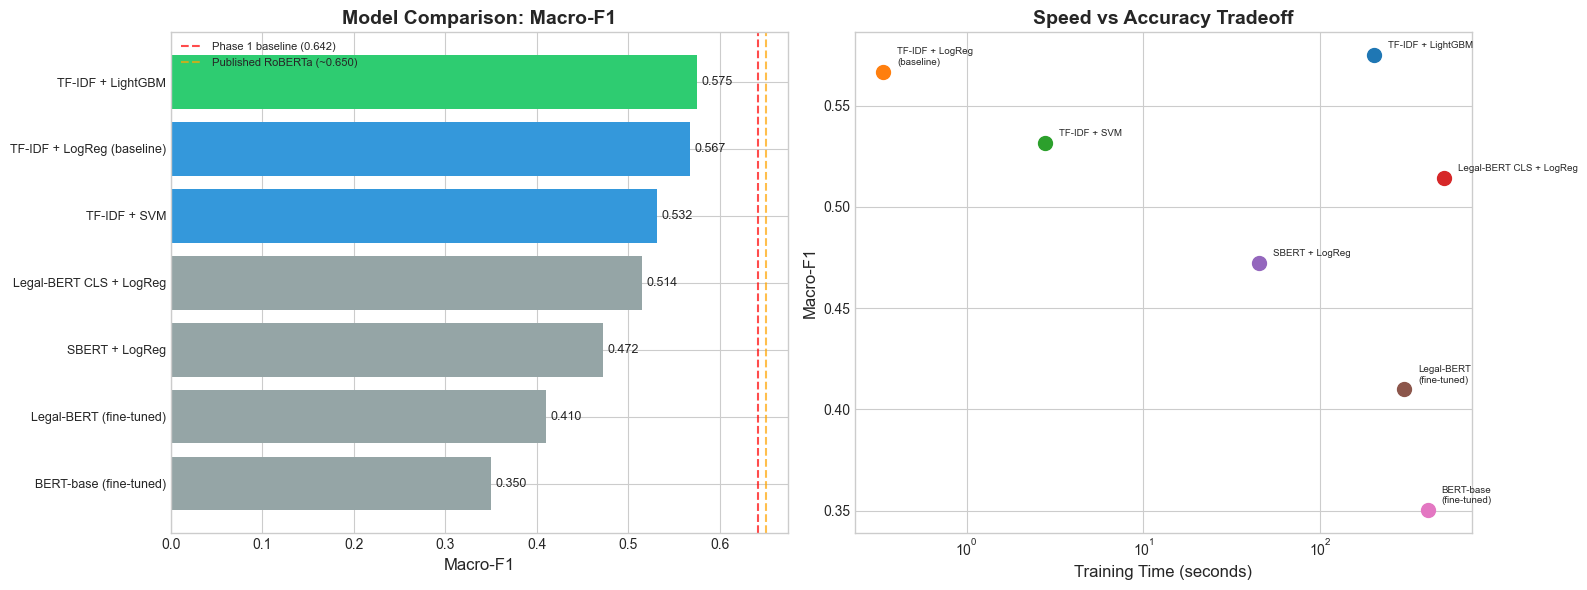

Saved: results/phase2_model_comparison.png


In [17]:
# Visualization: Model comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Macro-F1 comparison
colors = ['#2ecc71' if i == 0 else '#3498db' if i < 3 else '#95a5a6' for i in range(len(comp_df))]
ax1 = axes[0]
bars = ax1.barh(range(len(comp_df)), comp_df['Macro-F1'].values, color=colors)
ax1.set_yticks(range(len(comp_df)))
ax1.set_yticklabels(comp_df['Model'].values, fontsize=9)
ax1.set_xlabel('Macro-F1', fontsize=12)
ax1.set_title('Model Comparison: Macro-F1', fontsize=14, fontweight='bold')
ax1.axvline(x=0.642, color='red', linestyle='--', alpha=0.7, label='Phase 1 baseline (0.642)')
ax1.axvline(x=0.650, color='orange', linestyle='--', alpha=0.7, label='Published RoBERTa (~0.650)')
for i, v in enumerate(comp_df['Macro-F1'].values):
    ax1.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
ax1.legend(fontsize=8)
ax1.invert_yaxis()

# Speed vs accuracy tradeoff
ax2 = axes[1]
for _, row in comp_df.iterrows():
    ax2.scatter(row['Time (s)'], row['Macro-F1'], s=100, zorder=5)
    ax2.annotate(row['Model'].replace(' (fine-tuned)', '\n(fine-tuned)').replace(' (baseline)', '\n(baseline)'),
                 (row['Time (s)'], row['Macro-F1']),
                 textcoords='offset points', xytext=(10, 5), fontsize=7)
ax2.set_xlabel('Training Time (seconds)', fontsize=12)
ax2.set_ylabel('Macro-F1', fontsize=12)
ax2.set_title('Speed vs Accuracy Tradeoff', fontsize=14, fontweight='bold')
ax2.set_xscale('log')

plt.tight_layout()
plt.savefig(str(project_root / 'results' / 'phase2_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/phase2_model_comparison.png')

## Per-Clause Analysis: Where Do Transformers Win (and Lose)?
The aggregate macro-F1 hides important per-clause differences. Let's see which clause types benefit most from transformers vs classical ML.

In [18]:
# Per-clause comparison: best classical vs best transformer
# Pick the best classical model and best transformer from results
classical_models = ['TF-IDF + LogReg (baseline)', 'TF-IDF + SVM', 'TF-IDF + LightGBM']
transformer_models = ['BERT-base (fine-tuned)', 'Legal-BERT (fine-tuned)']

best_classical_name = max(classical_models, key=lambda m: all_results[m]['macro_f1'])
best_transformer_name = max(transformer_models, key=lambda m: all_results[m]['macro_f1'])

bc = all_results[best_classical_name].get('per_clause', {})
bt = all_results[best_transformer_name].get('per_clause', {})

print(f'Best classical: {best_classical_name}')
print(f'Best transformer: {best_transformer_name}')
print()

# Compare per-clause
clause_comparison = []
for clause in label_cols:
    c_f1 = bc.get(clause, {}).get('f1', 0)
    t_f1 = bt.get(clause, {}).get('f1', 0)
    if c_f1 > 0 or t_f1 > 0:  # Only clauses with some signal
        clause_comparison.append({
            'Clause': clause,
            f'{best_classical_name} F1': c_f1,
            f'{best_transformer_name} F1': t_f1,
            'Delta': t_f1 - c_f1,
            'Winner': 'Transformer' if t_f1 > c_f1 else 'Classical' if c_f1 > t_f1 else 'Tie',
            'High Risk': 'YES' if clause in HIGH_RISK_CLAUSES else ''
        })

clause_df = pd.DataFrame(clause_comparison).sort_values('Delta', ascending=False)
print('Per-Clause: Transformer vs Classical (sorted by transformer advantage)')
print(clause_df.to_string(index=False, float_format='%.3f'))

n_transformer_wins = (clause_df['Winner'] == 'Transformer').sum()
n_classical_wins = (clause_df['Winner'] == 'Classical').sum()
print(f'\nTransformer wins: {n_transformer_wins}/{len(clause_df)} clauses')
print(f'Classical wins: {n_classical_wins}/{len(clause_df)} clauses')

Best classical: TF-IDF + LightGBM
Best transformer: Legal-BERT (fine-tuned)

Per-Clause: Transformer vs Classical (sorted by transformer advantage)
                            Clause  TF-IDF + LightGBM F1  Legal-BERT (fine-tuned) F1  Delta      Winner High Risk
 Unlimited/All-You-Can-Eat-License                 0.000                       0.400  0.400 Transformer          
           Third Party Beneficiary                 0.000                       0.235  0.235 Transformer          
                Volume Restriction                 0.300                       0.377  0.077 Transformer          
                 Change Of Control                 0.512                       0.581  0.069 Transformer       YES
       Termination For Convenience                 0.519                       0.494 -0.024   Classical          
                 Non-Disparagement                 0.250                       0.172 -0.078   Classical          
                     License Grant                 0.8

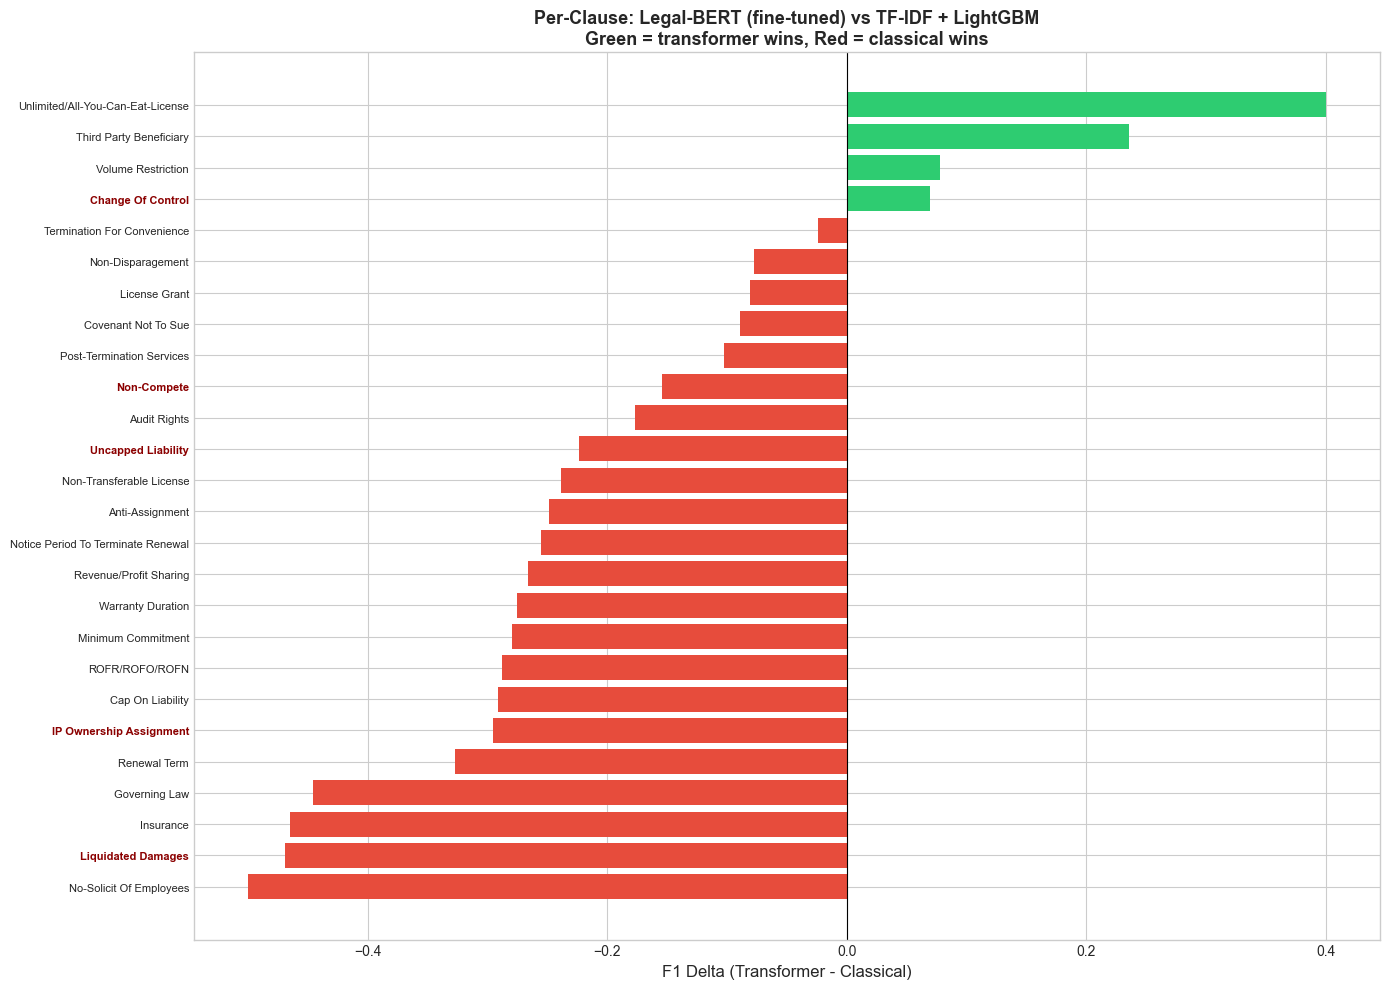

Saved: results/phase2_per_clause_delta.png


In [19]:
# Visualization: Per-clause delta (transformer - classical)
fig, ax = plt.subplots(figsize=(14, 10))

clause_df_sorted = clause_df.sort_values('Delta')
colors_delta = ['#2ecc71' if d > 0 else '#e74c3c' for d in clause_df_sorted['Delta']]
ax.barh(range(len(clause_df_sorted)), clause_df_sorted['Delta'].values, color=colors_delta)
ax.set_yticks(range(len(clause_df_sorted)))
ax.set_yticklabels(clause_df_sorted['Clause'].values, fontsize=8)
ax.set_xlabel('F1 Delta (Transformer - Classical)', fontsize=12)
ax.set_title(f'Per-Clause: {best_transformer_name} vs {best_classical_name}\nGreen = transformer wins, Red = classical wins',
             fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)

# Mark high-risk clauses
for i, (_, row) in enumerate(clause_df_sorted.iterrows()):
    if row['High Risk'] == 'YES':
        ax.get_yticklabels()[i].set_fontweight('bold')
        ax.get_yticklabels()[i].set_color('darkred')

plt.tight_layout()
plt.savefig(str(project_root / 'results' / 'phase2_per_clause_delta.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/phase2_per_clause_delta.png')

## Training Dynamics: Did the Transformers Converge?

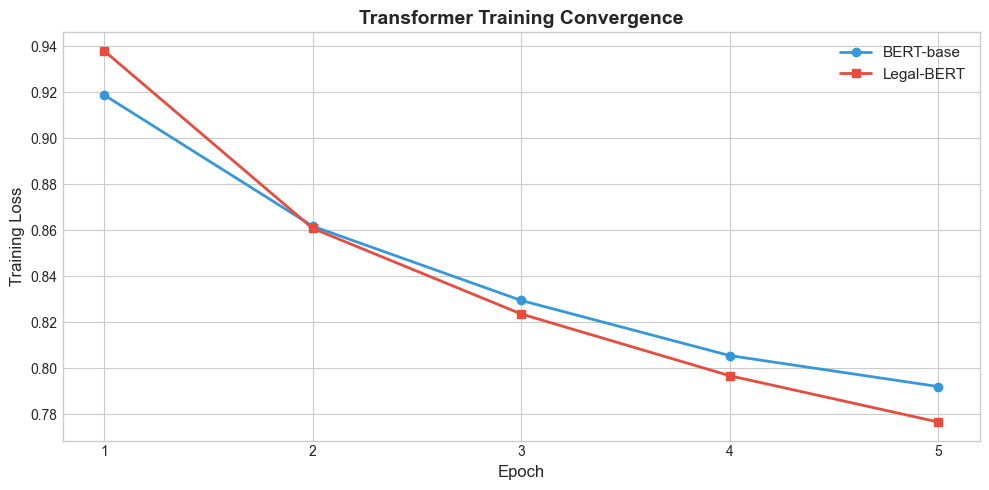

Saved: results/phase2_training_curves.png


In [20]:
# Plot training losses for both transformers
fig, ax = plt.subplots(figsize=(10, 5))

if 'train_losses' in all_results.get('BERT-base (fine-tuned)', {}):
    ax.plot(range(1, 6), all_results['BERT-base (fine-tuned)']['train_losses'],
            'o-', label='BERT-base', color='#3498db', linewidth=2)
if 'train_losses' in all_results.get('Legal-BERT (fine-tuned)', {}):
    ax.plot(range(1, 6), all_results['Legal-BERT (fine-tuned)']['train_losses'],
            's-', label='Legal-BERT', color='#e74c3c', linewidth=2)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.set_title('Transformer Training Convergence', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(range(1, 6))

plt.tight_layout()
plt.savefig(str(project_root / 'results' / 'phase2_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/phase2_training_curves.png')

## Key Findings & Interpretation

In [21]:
# Print structured findings
print('='*80)
print('PHASE 2 KEY FINDINGS')
print('='*80)

# Rank models
ranked = sorted(all_results.items(), key=lambda x: x[1]['macro_f1'], reverse=True)

print(f'\n1. CHAMPION: {ranked[0][0]} — Macro-F1 = {ranked[0][1]["macro_f1"]:.4f}')
print(f'2. Runner-up: {ranked[1][0]} — Macro-F1 = {ranked[1][1]["macro_f1"]:.4f}')
print(f'3. Third: {ranked[2][0]} — Macro-F1 = {ranked[2][1]["macro_f1"]:.4f}')

# Key deltas
baseline_f1 = lr_results['macro_f1']
best_f1 = ranked[0][1]['macro_f1']
print(f'\nBest vs Phase 1 baseline (TF-IDF+LR): {best_f1 - baseline_f1:+.4f}')
print(f'Best vs Published RoBERTa (~0.650): {best_f1 - 0.650:+.4f}')

# Domain pre-training effect
bert_f1 = all_results.get('BERT-base (fine-tuned)', {}).get('macro_f1', 0)
lbert_f1 = all_results.get('Legal-BERT (fine-tuned)', {}).get('macro_f1', 0)
print(f'\nDomain pre-training effect (Legal-BERT vs BERT-base): {lbert_f1 - bert_f1:+.4f}')

# Embedding comparison
sbert_f1 = all_results.get('SBERT + LogReg', {}).get('macro_f1', 0)
legal_cls_f1 = all_results.get('Legal-BERT CLS + LogReg', {}).get('macro_f1', 0)
print(f'Frozen embeddings: Legal-BERT CLS vs Sentence-BERT: {legal_cls_f1 - sbert_f1:+.4f}')

print('\n' + '='*80)

PHASE 2 KEY FINDINGS

1. CHAMPION: TF-IDF + LightGBM — Macro-F1 = 0.5750
2. Runner-up: TF-IDF + LogReg (baseline) — Macro-F1 = 0.5669
3. Third: TF-IDF + SVM — Macro-F1 = 0.5316

Best vs Phase 1 baseline (TF-IDF+LR): +0.0082
Best vs Published RoBERTa (~0.650): -0.0750

Domain pre-training effect (Legal-BERT vs BERT-base): +0.0597
Frozen embeddings: Legal-BERT CLS vs Sentence-BERT: +0.0423



## Save All Results

In [22]:
# Save metrics (exclude non-serializable items)
save_results = {}
for name, res in all_results.items():
    save_results[name] = {k: v for k, v in res.items() if k != 'train_losses'}

metrics_path = project_root / 'results' / 'phase2_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump({
        'phase': 2,
        'date': '2026-04-14',
        'dataset': 'CUAD v1',
        'primary_metric': 'macro_f1',
        'n_train': len(train_texts),
        'n_test': len(test_texts),
        'n_labels': len(label_cols),
        'results': save_results
    }, f, indent=2, default=str)
print(f'Saved: {metrics_path}')

# Update experiment log
log_path = project_root / 'results' / 'EXPERIMENT_LOG.md'
with open(log_path, 'a') as f:
    f.write('\n\n## Phase 2: Multi-Model Comparison (2026-04-14)\n\n')
    f.write('| Rank | Model | Macro-F1 | Micro-F1 | Precision | Recall | AUC | Time (s) |\n')
    f.write('|------|-------|----------|----------|-----------|--------|-----|----------|\n')
    for _, row in comp_df.iterrows():
        star = '**' if row['Rank'] == 1 else ''
        f.write(f'| {row["Rank"]} | {star}{row["Model"]}{star} | {row["Macro-F1"]:.4f} | {row["Micro-F1"]:.4f} | {row["Precision"]:.4f} | {row["Recall"]:.4f} | {row["AUC"]:.4f} | {row["Time (s)"]:.1f} |\n')
    f.write(f'\n**Champion:** {ranked[0][0]} (Macro-F1={ranked[0][1]["macro_f1"]:.4f})\n')
    f.write(f'**Key insight:** Domain pre-training effect: Legal-BERT vs BERT-base = {lbert_f1 - bert_f1:+.4f}\n')
print(f'Updated: {log_path}')

print('\nPhase 2 complete. All results saved.')

Saved: /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/Legal-Contract-Analyzer/results/phase2_metrics.json
Updated: /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/Legal-Contract-Analyzer/results/EXPERIMENT_LOG.md

Phase 2 complete. All results saved.
